В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import xgboost as xgb
import lightgbm as lgb


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [2]:
raw_df = pd.read_csv(r'D:\ml_course\Модуль 2. Навчання з учителем\dataframes\bank-customer-churn-prediction-dlu-course-c-4\train.csv')
drop_columns = ['Surname', 'CustomerId', 'id']
raw_df = raw_df.drop(columns=drop_columns)
target_col = 'Exited'
input_cols = raw_df.columns.drop(target_col).to_list()
train_df, val_df = split_train_val(raw_df, target_col)
train_inputs, train_targets = separate_inputs_targets(train_df, input_cols, target_col)
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols, target_col)

1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [3]:
cat_features = train_inputs.select_dtypes('object').columns
train_inputs[cat_features] = train_inputs[cat_features].astype('category')
val_inputs[cat_features] = val_inputs[cat_features].astype('category')
print(train_inputs.info())

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 7180 to 9360
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      12000 non-null  float64 
 1   Geography        12000 non-null  category
 2   Gender           12000 non-null  category
 3   Age              12000 non-null  float64 
 4   Tenure           12000 non-null  float64 
 5   Balance          12000 non-null  float64 
 6   NumOfProducts    12000 non-null  float64 
 7   HasCrCard        12000 non-null  float64 
 8   IsActiveMember   12000 non-null  float64 
 9   EstimatedSalary  12000 non-null  float64 
dtypes: category(2), float64(8)
memory usage: 867.4 KB
None


2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [4]:
xgb_clf = XGBClassifier(
    max_depth=4,
    n_estimators=100,
    learning_rate = 0.05,
    enable_categorical=True,
    missing=np.nan,
    random_state = 42
)
xgb_clf.fit(train_inputs, train_targets)

train_probs = xgb_clf.predict_proba(train_inputs)[:, 1]
val_probs = xgb_clf.predict_proba(val_inputs)[:, 1]
print('ROC AUC train:', round(roc_auc_score(train_targets, train_probs), 4))
print('ROC AUC val:', round(roc_auc_score(val_targets, val_probs), 4))

ROC AUC train: 0.9429
ROC AUC val: 0.9366


XGBoost справився краще порівняно з одним деревом рішень. Розрив між train та val невеликий, отже модель не перенавчена. Бустинг покращив якість за рахунок послідовного навчання слабких дерев.

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [5]:
def objective(params):
    clf = xgb.XGBClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        gamma=params['gamma'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        enable_categorical=True,
        missing=np.nan,
        early_stopping_rounds=10,
        eval_metric='auc',
        random_state=42,
        verbosity=0
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        verbose=False)
    probs = clf.predict_proba(val_inputs)[:, 1]
    roc_auc = roc_auc_score(val_targets, probs)

    return {'loss': -roc_auc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 100, 400, 25),
    'learning_rate': hp.uniform('learning_rate', 0.03, 0.15),
    'max_depth': hp.quniform('max_depth', 3, 8, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 6, 1),
    'subsample': hp.uniform('subsample', 0.7, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.3),
    'reg_alpha': hp.uniform('reg_alpha', 0, 0.5),
    'reg_lambda': hp.uniform('reg_lambda', 0.5, 2)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials, rstate=np.random.default_rng(42))

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    missing=np.nan,
    early_stopping_rounds=10,
    random_state=42,
    verbosity=0
)

final_clf.fit(train_inputs, 
              train_targets,
              eval_set=[(val_inputs, val_targets)],
              verbose=False)
train_probs_xgb = final_clf.predict_proba(train_inputs)[:, 1]
val_probs_xgb = final_clf.predict_proba(val_inputs)[:, 1]

train_roc_auc_xgb = roc_auc_score(train_targets, train_probs_xgb)
val_roc_auc_xgb = roc_auc_score(val_targets, val_probs_xgb)

print("Точність на тренувальній вибірці: {:.4f}".format(train_roc_auc_xgb))
print("Точність на валідаційній вибірці: {:.4f}".format(val_roc_auc_xgb))

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 20/20 [00:04<00:00,  4.44trial/s, best loss: -0.9383136703477606]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.8025617911517091), 'gamma': np.float64(0.0016464099764485816), 'learning_rate': np.float64(0.1361858368950512), 'max_depth': 3, 'min_child_weight': 4, 'n_estimators': 125, 'reg_alpha': np.float64(0.43046524095671734), 'reg_lambda': np.float64(1.4123737432567047), 'subsample': np.float64(0.7901264064371525)}
Точність на тренувальній вибірці: 0.9431
Точність на валідаційній вибірці: 0.9383


Після підбору гіперпараметрів за допомогою Hyperopt якість моделі не змінилася суттєво. Різниця в ROC AUC становить 0.0017, що свідчить про те, що початково обрані параметри вже були близькими до оптимальних. Модель не демонструє ознак high bias або high variance

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [6]:
cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in cat_features]
lgb_clf = lgb.LGBMClassifier(
    max_depth=4,
    n_estimators=50,
    learning_rate=0.1,
    cat_feature=cat_feature_indexes,
    missing=np.nan,
    random_state = 42,
    verbosity=-1
)

lgb_clf.fit(train_inputs, 
            train_targets, 
            eval_set=[(val_inputs, val_targets)]            
)

train_probs_lgb = lgb_clf.predict_proba(train_inputs)[:, 1]
val_probs_lgb = lgb_clf.predict_proba(val_inputs)[:, 1]
print('ROC AUC train:', round(roc_auc_score(train_targets, train_probs_lgb), 4))
print('ROC AUC val:', round(roc_auc_score(val_targets, val_probs_lgb), 4))

ROC AUC train: 0.9439
ROC AUC val: 0.9369


LightGBM показала ROC AUC 0.9369 на валідаційній вибірці. Різниця між train та val невелика 0.007, що свідчить про відсутність сильного перенавчання. Якість моделі практично не відрізняється від XGBoost 0.9383.

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [18]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),  # Кількість дерев у ансамблі (кількість ітерацій бустингу)
        learning_rate=params['learning_rate'],  # Коефіцієнт, на який зменшується внесок кожного доданого дерева
        max_depth=int(params['max_depth']),  # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']),  # Максимальна кількість листків, що дозволяємо кожному дереву мати.
        min_child_samples=int(params['min_child_samples']),
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        cat_feature=cat_feature_indexes,  # Індекси категорійних ознак
        eval_metric='auc',
        random_state=42,
        verbosity=-1
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)]
)
    probs = clf.predict_proba(val_inputs)[:, 1]
    roc_auc = roc_auc_score(val_targets, probs)

    return {'loss': -roc_auc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 100, 400, 25),
    'learning_rate': hp.uniform('learning_rate', 0.03, 0.15),
    'max_depth': hp.quniform('max_depth', 3, 8, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 80, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 6, 1),
    'subsample': hp.uniform('subsample', 0.7, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 0.5),
    'reg_lambda': hp.uniform('reg_lambda', 0.5, 2),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.05),
    'min_child_samples': hp.quniform('min_child_samples', 10, 100, 5)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials, rstate=np.random.default_rng(42))

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_samples'] = int(best['min_child_samples'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_lgb_clf = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    cat_feature=cat_feature_indexes,
    missing=np.nan,
    random_state=42,
    verbosity=-1
)

final_lgb_clf.fit(train_inputs, 
            train_targets,
            eval_set=[(val_inputs, val_targets)]
)
train_probs_lgb = final_lgb_clf.predict_proba(train_inputs)[:, 1]
val_probs_lgb = final_lgb_clf.predict_proba(val_inputs)[:, 1]

train_roc_auc_lgb = roc_auc_score(train_targets, train_probs_lgb)
val_roc_auc_lgb = roc_auc_score(val_targets, val_probs_lgb)

print("Точність на тренувальній вибірці: {:.4f}".format(train_roc_auc_lgb))
print("Точність на валідаційній вибірці: {:.4f}".format(val_roc_auc_lgb))

  0%|          | 0/10 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 10/10 [00:04<00:00,  2.02trial/s, best loss: -0.9365357706289869]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.9947734409264329), 'learning_rate': np.float64(0.051873933133509464), 'max_depth': 4, 'min_child_samples': 65, 'min_child_weight': 2, 'min_split_gain': np.float64(0.025037530494753647), 'n_estimators': 125, 'num_leaves': 62, 'reg_alpha': np.float64(0.29622670666290374), 'reg_lambda': np.float64(0.8183256754900028), 'subsample': np.float64(0.8211333010785937)}
Точність на тренувальній вибірці: 0.9448
Точність на валідаційній вибірці: 0.9372


Після підбору гіперпараметрів за допомогою Hyperopt модель LightGBM показала покращення якості. Значення AUROC на валідаційній вибірці становить 0.9372, що є трохи кращим за результат попередньої моделі. Різниця між train та validation невелика, тому модель не має  перенавчання.

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [25]:
test_raw_df = pd.read_csv(
    r'D:\ml_course\Модуль 2. Навчання з учителем\dataframes\bank-customer-churn-prediction-dlu-course-c-4\test.csv'
)
X_test = test_raw_df[input_cols].copy()
X_test[cat_features] = X_test[cat_features].astype('category')
test_probs = final_clf.predict_proba(X_test)[:, 1]

In [26]:
print(X_test.shape)
print(len(test_probs))

(10000, 10)
10000


In [27]:
submission_df = pd.read_csv(r'D:\ml_course\Модуль 2. Навчання з учителем\dataframes\bank-customer-churn-prediction-dlu-course-c-4\sample_submission.csv')
submission_df['Exited'] = test_probs
submission_df.head()

,id,Exited
0,15000,0.074774
1,15001,0.014494
2,15002,0.061554
3,15003,0.504206
4,15004,0.031676


In [28]:
submission_df.to_csv('submission_xgb.csv', index=False)

Для фінального сабміту була обрана модель XGBoost з оптимізованими гіперпараметрами, оскільки вона показала найкраще значення ROC AUC на валідаційній вибірці 0.9383 порівняно з іншими моделями. Різниця між train та val метриками є невеликою, що свідчить про хорошу модель та відсутність  перенавчання.

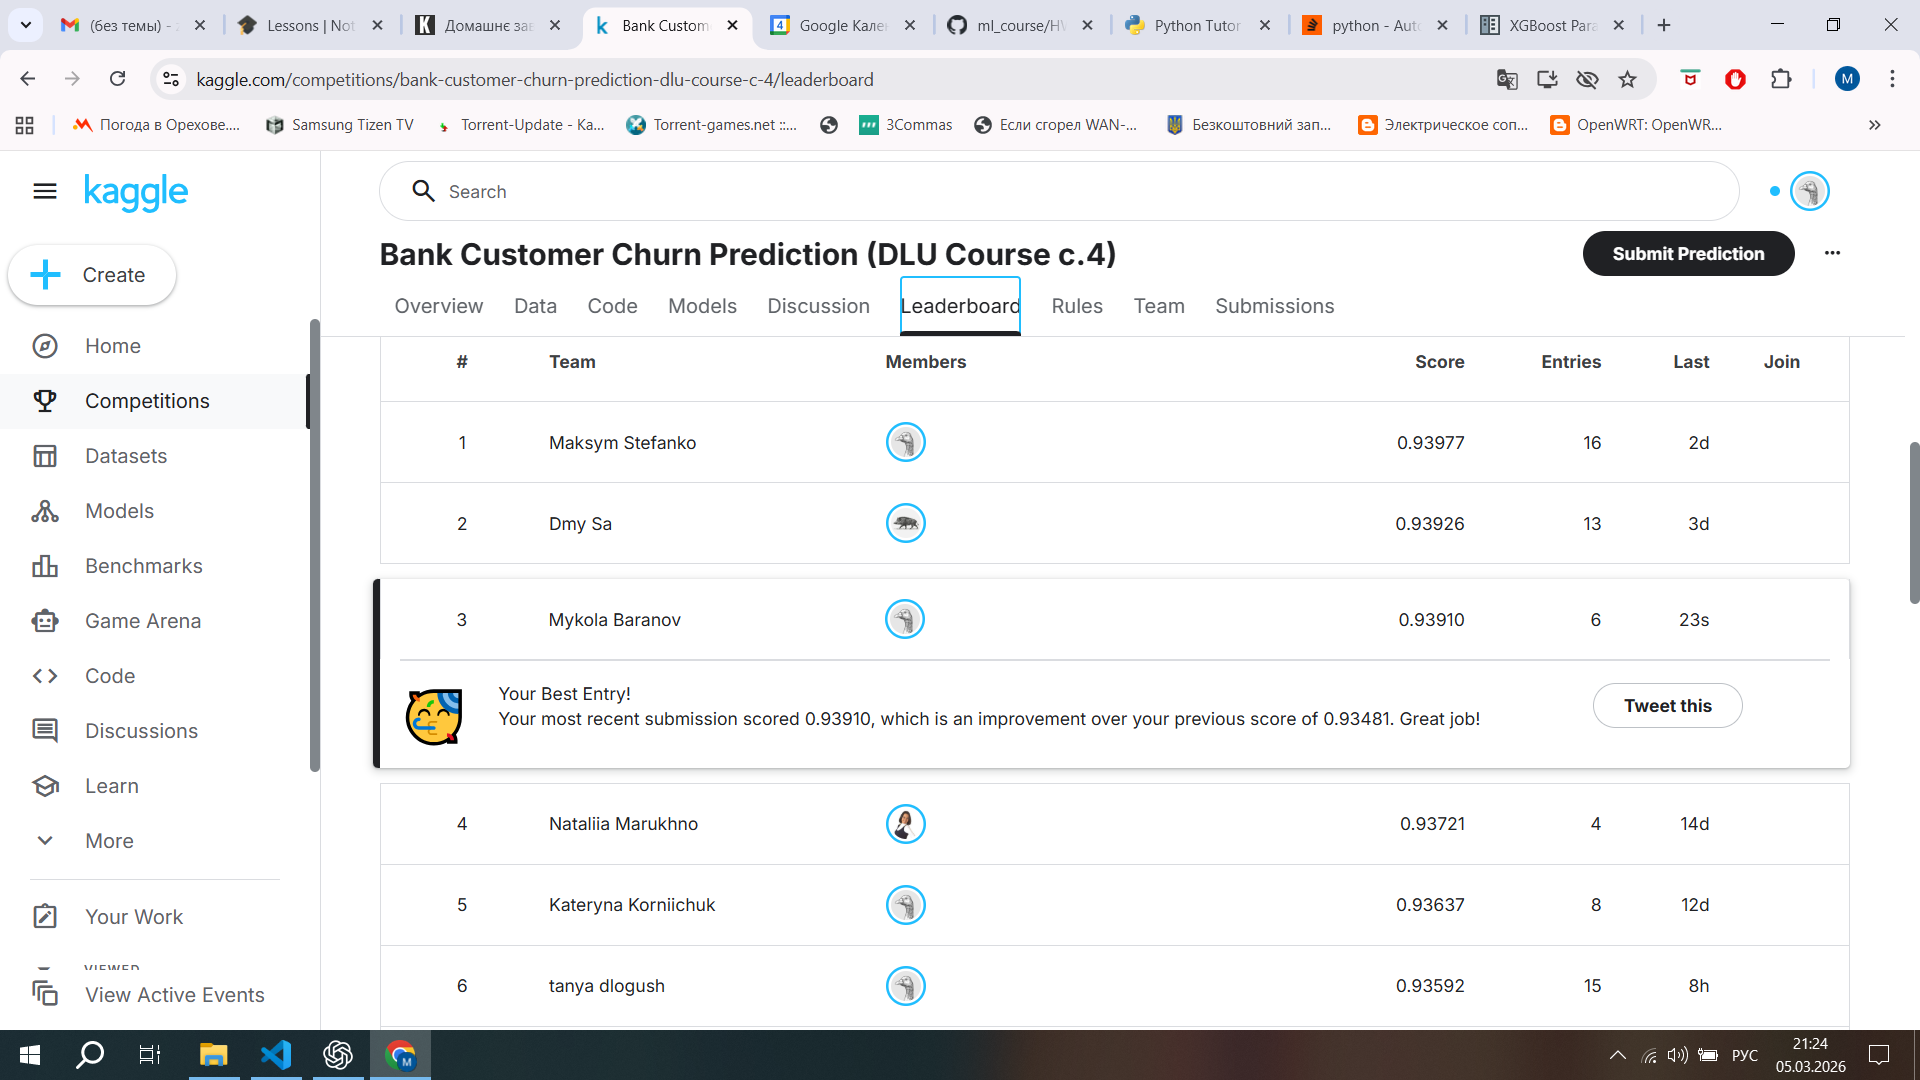